## Galaxy and quasar 1

Define the needed functions. Load the data and scale the features even though in this case values of magnitude are quite similare

In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from astroML.classification import GMMBayes
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from astroML.utils import split_samples, completeness_contamination
import astropy.visualization.hist
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import corner
from sklearn.model_selection import GridSearchCV

df = pd.read_csv('galaxyquasar.csv')
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

feature_names = df.columns[-4:]
X = df[feature_names].to_numpy()
y = df['class_encoded'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_feature_names = ['s_' + name for name in feature_names]

# Add the scaled features to the DataFrame
for i, col in enumerate(scaled_feature_names):
    df[col] = X_scaled[:, i]

Perform a corner plot to see joint probabilities and correlations

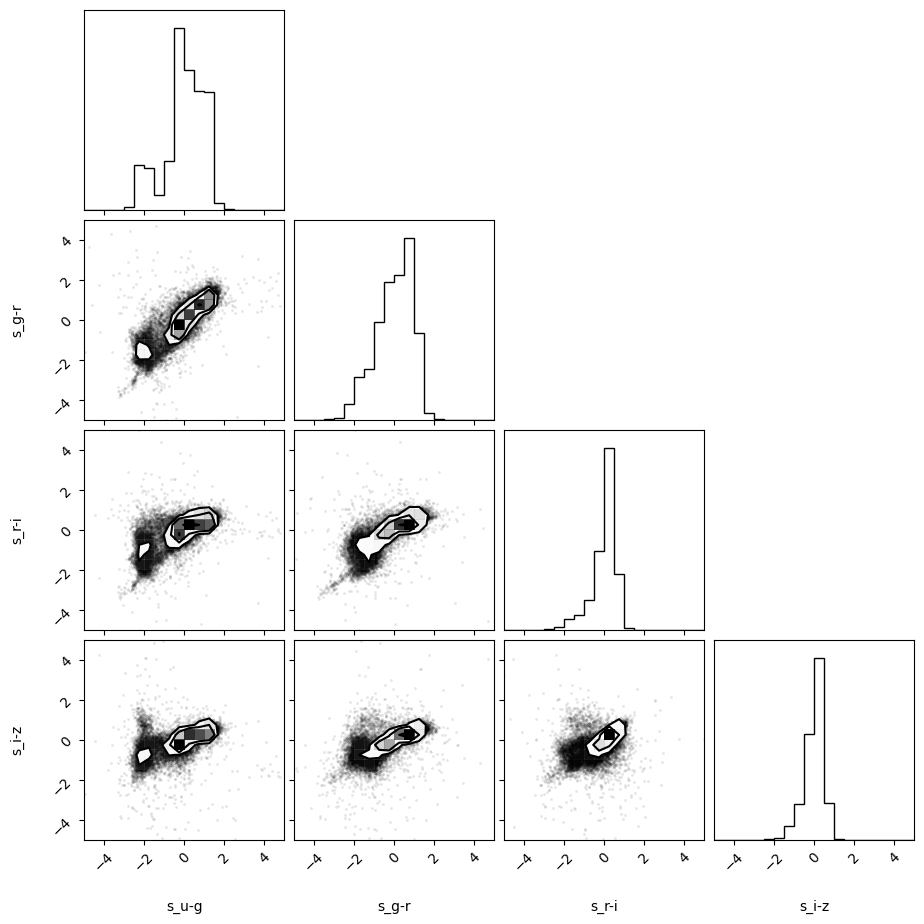

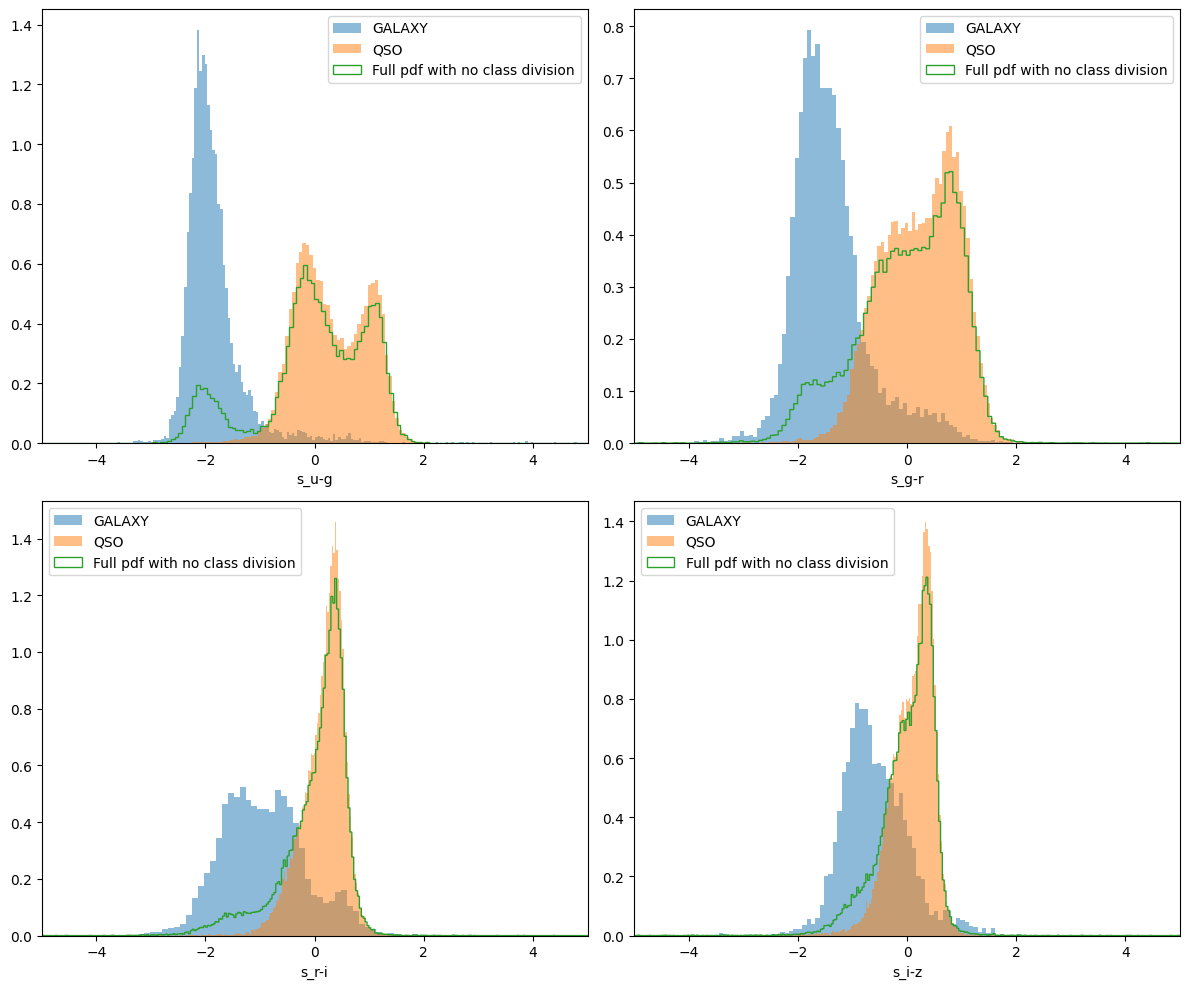

In [37]:
ranges = [(-5, 5), (-5, 5), (-5, 5), (-5, 5)]
corner.corner(df[scaled_feature_names], labels=scaled_feature_names, range=ranges);

fig, axes = plt.subplots(2, 2,figsize=(12, 10))
class_labels = le.classes_
class_values = df['class_encoded'].unique()
colors = plt.get_cmap('tab10').colors
for ax, feature in zip(axes.flatten(), scaled_feature_names):
    for idx, (class_value, class_label) in enumerate(zip(class_values, class_labels)):
        data = df[df['class_encoded'] == class_value][feature]
        astropy.visualization.hist(data, bins="freedman",density=True, label=class_label, ax = ax, alpha = 0.5)
    astropy.visualization.hist(df[feature], bins="freedman",density=True,histtype="step", label= 'Full pdf with no class division', ax = ax)
    ax.set_xlabel(feature)
    ax.set_xlim(-5, 5) 
    ax.legend()
    
plt.tight_layout()

There's seems to be positive correlations everywhere but especially for the u-g feature. So the statistican independece could be violated.

It seems that u-g has the best separation between classes. Could be the most important feature. Overall there are multimodalities in every feature. Thus, also the hypothesis of gaussianity is not so solid.

Now train some models with a different number of features

In [38]:
#%%
(X_train, X_test), (y_train, y_test) = split_samples(X_scaled, y, [0.75, 0.25],random_state=0)



#------------------------------------------------------------
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    nfeatures = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        for ifeature,_ in enumerate(scaled_feature_names):
            clf.fit(X_train[:,0:ifeature+1], y_train)
            #Note that we are outputing the probabilities [of class 1], not the classes
            y_probs = clf.predict_proba(X_test[:,0:ifeature+1])[:, 1]
    
            names.append(classifier.__name__)
            probs.append(y_probs)
            nfeatures.append(ifeature)

    return names, probs, nfeatures


names, probs, nfeatures = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression,
                                dict(class_weight='balanced')),
                              (KNeighborsClassifier,
                                dict(n_neighbors=5)),
                              (GMMBayes, dict(n_components=5, tol=1E-5,
                                              covariance_type='full')))

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
GMMBayes


C:\Anaconda\Lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


Plot the results

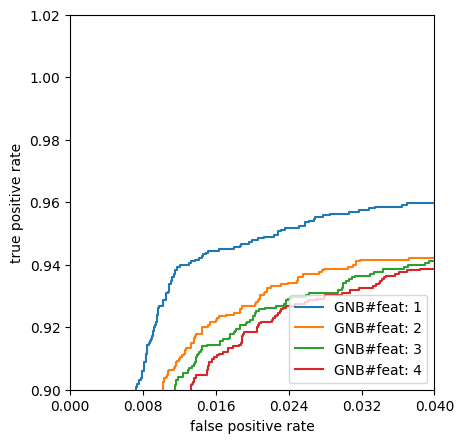

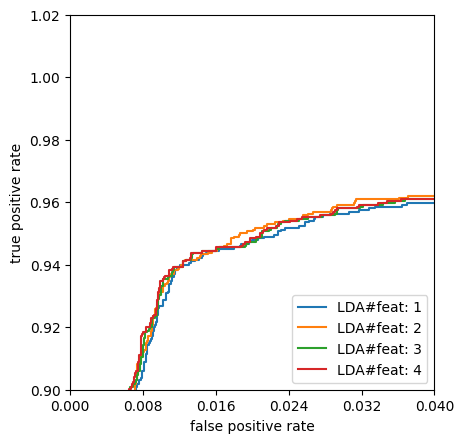

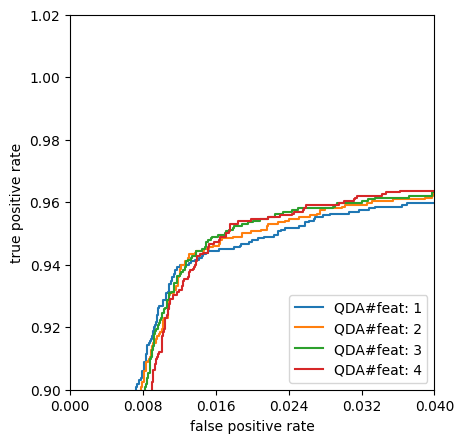

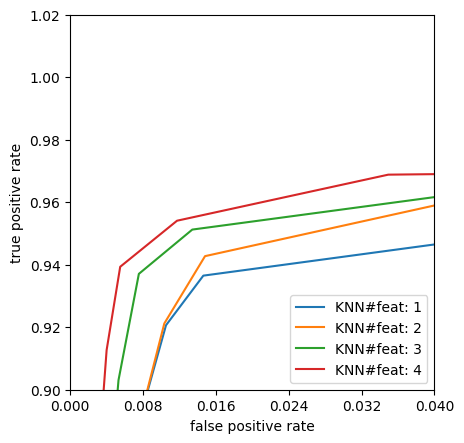

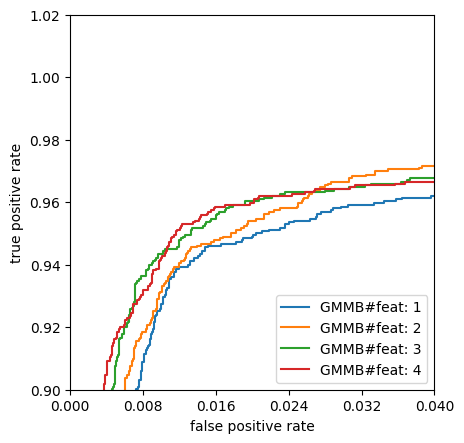

In [39]:

def SelModel(name,number_features = None):
    index = np.where(np.array(names) == name)[0]
    if number_features is not None:
        index = np.where(np.array(nfeatures) == number_features-1)[0]
    index = np.intersect1d(index,np.where(np.array(names) == name)[0])
    return np.array(names)[index], np.array(probs)[index], np.array(nfeatures)[index]

def PlotModel(setylim=True):
    labels = dict(GaussianNB='GNB',
                  LinearDiscriminantAnalysis='LDA',
                  QuadraticDiscriminantAnalysis='QDA',
                  KNeighborsClassifier='KNN',
                  DecisionTreeClassifier='DT',
                  GMMBayes='GMMB',
                  LogisticRegression='LR')
    # Plot ROC curves and completeness/efficiency
    fig = plt.figure(figsize=(15, 5))
    fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)

    # ax1 will show roc curves
    ax1 = plt.subplot(131)
    
    # ax2 will show completeness/efficiency
    # ax2 = plt.subplot(132)
    
    # ax3 will show precision/recall
    # ax3 = plt.subplot(133)

    # iterate through and show results
    for name, y_prob, ifeature in zip(names_sel, probs_sel, nfeatures_sel):
        fpr, tpr, thresh = roc_curve(y_test, y_prob)
        precision, recall, thresh2 = precision_recall_curve(y_test, y_prob)
    
        # add (0, 0) as first point
        fpr = np.concatenate([[0], fpr])
        tpr = np.concatenate([[0], tpr])
        # Here we add (1,0) 
        precision = np.concatenate([[0], precision])
        recall = np.concatenate([[1], recall])
        thresh2 = np.concatenate([[0], thresh2])
    
        ax1.plot(fpr, tpr, label=[labels[name]+'#feat: '+str(ifeature+1)])
    
        #See note above about astroML vs. sklearn
        #Note that the range of threshhold values here is 0% to 100% (0.0 to 1.0)
        thresholds = np.linspace(0, 1, 1001)[:-1]
        comp = np.zeros_like(thresholds)
        cont = np.zeros_like(thresholds)
        for i, t in enumerate(thresholds):
            y_pred = (y_prob >= t)
            comp[i], cont[i] = completeness_contamination(y_pred, y_test)
        # ax2.plot(1 - cont, comp, label=labels[name])
        print(f'Completeness'+[labels[name]+'#feat: '+str(ifeature+1)], tpr)
        #ax3.plot(precision, recall, label=labels[name])
    
    ax1.set_xlim(0, 0.04)
    if setylim:
        ax1.set_ylim(0.9, 1.02)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax1.set_xlabel('false positive rate')
    ax1.set_ylabel('true positive rate')
    ax1.legend(loc=4)
    
    
    # ax2.set_xlabel('efficiency')
    # ax2.set_ylabel('completeness')
    # ax2.set_xlim(0, 1.0)
    # ax2.set_ylim(0.2, 1.02)
    
    #ax3.set_xlabel('precision')
    #ax3.set_ylabel('recall')
    #ax3.set_xlim(0, 1.0)
    #ax3.set_ylim(0.2, 1.02)
    
    plt.show()

for model_name in ['GaussianNB','LinearDiscriminantAnalysis','QuadraticDiscriminantAnalysis','KNeighborsClassifier','GMMBayes']:
    names_sel, probs_sel, nfeatures_sel = SelModel(model_name)
    PlotModel()

In general it seems that the more features, the better it is but the first feature alone (u-g) is enogh to reach a high level of TPR.

Indeed, if we exclude the first feature the overall 3 features sum up to roughly 70%

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
GMMBayes


C:\Anaconda\Lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


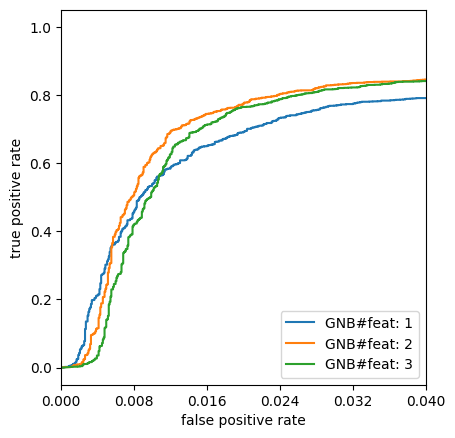

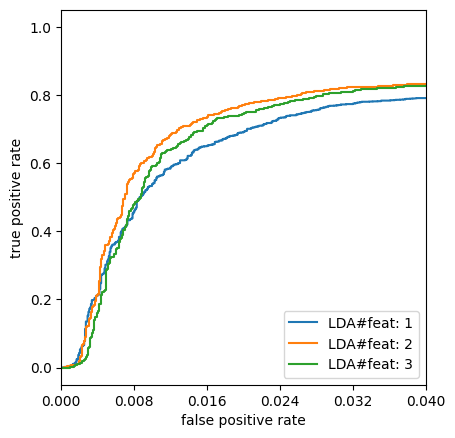

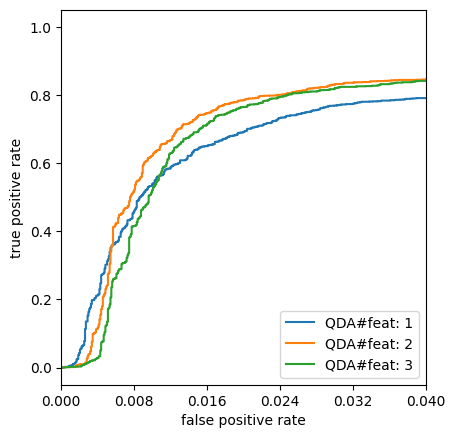

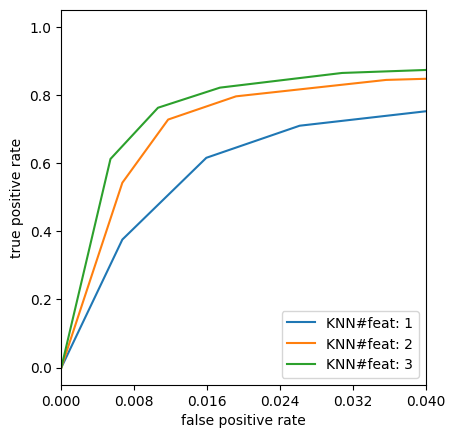

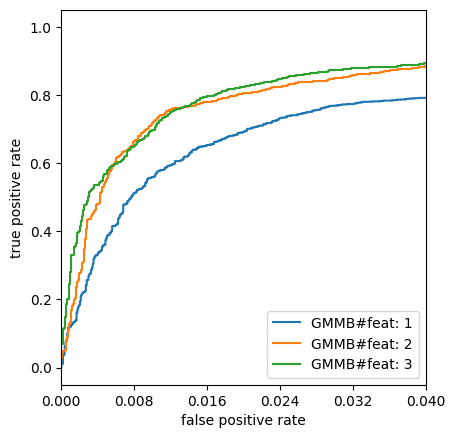

In [40]:
scaled_feature_names = ['s_g-r', 's_r-i', 's_i-z']
X_scaled = df[scaled_feature_names].to_numpy()


(X_train, X_test), (y_train, y_test) = split_samples(X_scaled, y, [0.75, 0.25],random_state=0)


names, probs, nfeatures = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression,
                                dict(class_weight='balanced')),
                              (KNeighborsClassifier,
                                dict(n_neighbors=5)),
                              (GMMBayes, dict(n_components=5, tol=1E-5,
                                              covariance_type='full')))

for model_name in ['GaussianNB','LinearDiscriminantAnalysis','QuadraticDiscriminantAnalysis','KNeighborsClassifier','GMMBayes']:
    names_sel, probs_sel, nfeatures_sel = SelModel(model_name)
    PlotModel(False)

Cross validate KNC and GMM using all the features

In [41]:
scaled_feature_names = ['s_u-g','s_g-r', 's_r-i', 's_i-z']
X_scaled = df[scaled_feature_names].to_numpy()


(X_train, X_test), (y_train, y_test) = split_samples(X_scaled, y, [0.75, 0.25],random_state=0)

Best estimator:  {'n_neighbors': 6}


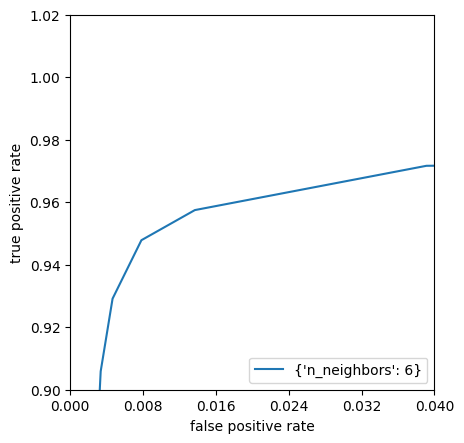

In [43]:
clf = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': np.arange(2,20,2)}, cv= 5)
clf.fit(X_train[:,0:4], y_train)
print('Best estimator: ', clf.best_params_)
y_probs = clf.predict_proba(X_test[:,0:4])[:, 1]
fpr, tpr, thresh = roc_curve(y_test, y_probs)
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)
ax1 = plt.subplot(131)
ax1.plot(fpr, tpr, label = str(clf.best_params_))
ax1.set_xlim(0, 0.04)
ax1.set_ylim(0.9, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)

Best estimator:  12


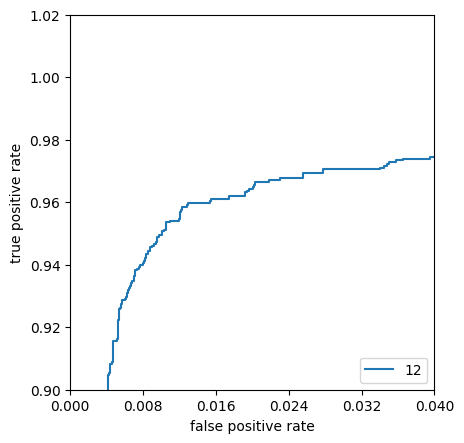

In [44]:
best_score = -np.inf
best_n = None
for n in range(2, 18, 2):
    clf = GMMBayes(n_components=n)
    clf.fit(X_train[:,0:4], y_train)
    score = clf.score(X_test[:,0:4], y_test)  # Use a validation set
    if score > best_score:
        best_score = score
        best_n = n
print('Best estimator: ', best_n)
clf = GMMBayes(n_components=best_n)
clf.fit(X_train[:,0:4], y_train)
y_probs = clf.predict_proba(X_test[:,0:4])[:, 1]
fpr, tpr, thresh = roc_curve(y_test, y_probs)
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)
ax1 = plt.subplot(131)
ax1.plot(fpr, tpr, label = str(best_n))
ax1.set_xlim(0, 0.04)
ax1.set_ylim(0.9, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)    